In [24]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.optimize import minimize
from smooth_POD_ROM.post_processing import post_process, richardson_lucy
from smooth_POD_ROM.post_processing import get_sigma
from smooth_POD_ROM.reduced_order_model import optimize_hyperparameters, optimize_hyperparameters_single, snapshots # , build_DSROM_g
from smooth_POD_ROM.pre_processing import convolve_f, gaussian_f, gaussian, smoothen
from smooth_POD_ROM.initial_conditions import rectangular_pulse, rect_pulse_sin, saw_tooth, triangle
from smooth_POD_ROM.reduced_order_model import delta_n_width, train_ROM, L2_error, zielfunktion, make_data_rw
from smooth_POD_ROM.plots_paper import Fig3, Fig4, Fig5, Fig6, Fig7, Fig8, Fig11
import warnings
from scipy.ndimage import gaussian_filter
from scipy.signal import convolve2d as conv2
from scipy.interpolate._rgi_cython import evaluate_linear_2d, find_indices
from scipy.interpolate import (
    RegularGridInterpolator,
    RectBivariateSpline,
    interpn,
    griddata,
    Rbf,
    interp1d,
    interp2d,
)
from scipy.fft import fft, ifft, fftshift, ifftshift, fftfreq
from scipy.signal import wiener, butter, freqs, convolve, freqz
from scipy.signal import wiener
from scipy.ndimage import gaussian_filter1d
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, orth, qr
from scipy.optimize import curve_fit
from numpy import sin, cos, pi


In [25]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 45

8.030570172000001


In [26]:
n_x = 1000
x = np.linspace(0, 1, n_x, endpoint=False)
shape = x.shape
dx = x[1] - x[0]

n_train = 10
n_test = 10
g = rectangular_pulse
truncate = 12

progress = False
num_iter = 100
num_iter2 = 1000
monitor_convergence = False
clip=True

In [27]:
rank = [10, 20, 30, 50]
sigma = [0.08658411693500023, 0.06753569193117442, 0.04260935916899724, 0.01348455548077379]
c = [2.147755288610398, 0.5273285959317914, 0.3269542485762022, 0.6772697328198871]
improvements = [-82.8685,-72.4666, -64.0511, -60.1164]

# results for:
# n_x = 1000
# n_train = 10
# n_test = 10
# num_iter1 = 100
# num_iter2 = 1001
# clip = True

In [28]:
def build_DSROM_g(mu_train, g, x, sigma, n_test):
    dx = x[1] - x[0]
    rank = len(mu_train)
    mu_test = np.linspace(mu_train[1], mu_train[2], n_test, endpoint=False)

    X_train = snapshots(g, x, mu_train)
    X_train_s = smoothen(X_train, sigma / dx, x.shape, truncate=12)
    standard_rom = train_ROM(mu_train, X_train, rank=rank)
    X_test_ROM = standard_rom.predict(mu_test).snapshots_matrix.T

    X_test = snapshots(g, x, mu_test)
    X_test_s = smoothen(X_test, sigma / dx, x.shape, truncate=12)
    smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
    X_test_sROM = smooth_rom.predict(mu_test).snapshots_matrix.T
    return mu_test, X_test, X_test_ROM, X_test_s, X_test_sROM

In [5]:
print("optimize sigma and c for each rank. slow!")
for i, _rank in enumerate(rank):
    n_train = _rank
    mu_train = np.linspace([0.0], [1.0], n_train, endpoint=False)
    mu_test = np.linspace(mu_train[1], mu_train[2], n_test, endpoint=False)
    
    X_train = snapshots(g, x, mu_train)
    X_test = snapshots(g, x, mu_test)

    sigma[i], c[i] = optimize_hyperparameters(x, mu_train, mu_test, X_train, X_test, shape, num_iter2, clip, _rank)
    print(n_train, sigma[i], c[i])

optimize sigma and c for each rank. slow!
sigma, c, iteration count, mean_ROM, mean_sROM, mean_sROMs, improvement
post_process: 0.05 1.0 1000 (1000,) True


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


0.05000000, 1.00000000, 0, 0.18630632, 0.19064741, 0.09253357, -50.3326 %
post_process: 0.0505 1.0 1000 (1000,) True
0.05050000, 1.00000000, 1, 0.18630632, 0.19107114, 0.08859378, -52.4472 %
post_process: 0.05 1.05 1000 (1000,) True
0.05000000, 1.05000000, 2, 0.18630632, 0.19064741, 0.08362477, -55.1144 %
post_process: 0.2499809562739756 9.999999610063881 1000 (1000,) True
0.24998096, 9.99999961, 3, 0.18630632, 0.25416506, 0.22234466, 19.3436 %
post_process: 0.14606806833686967 5.3234745631823595 1000 (1000,) True
0.14606807, 5.32347456, 4, 0.18630632, 0.23847695, 0.11645989, -37.4901 %
post_process: 0.09729315752739905 3.128394659350228 1000 (1000,) True
0.09729316, 3.12839466, 5, 0.18630632, 0.22199498, 0.03310266, -82.2321 %
post_process: 0.07567610139157122 2.155534540976559 1000 (1000,) True
0.07567610, 2.15553454, 6, 0.18630632, 0.21009265, 0.03248384, -82.5643 %
post_process: 0.07617610139157122 2.155534540976559 1000 (1000,) True
0.07617610, 2.15553454, 7, 0.18630632, 0.2104129

recreate results exactly from above using ZF and post_pr:

In [35]:
params = [0.08658711379158776, 2.1672340746863146]
n_train = 10
_rank_ = 10
num_iter = 1000

mu_train = np.linspace([0.0], [1.0], n_train, endpoint=False)
mu_test = np.linspace(mu_train[1], mu_train[2], n_test, endpoint=False)

X_train = snapshots(g, x, mu_train)
X_test = snapshots(g, x, mu_test)

_sigma_, _c_ = params

standard_rom = train_ROM(mu_train, X_train, rank=_rank_)
X_test_ROM = standard_rom.predict(mu_test).snapshots_matrix.T

X_train_s = smoothen(X_train, _sigma_ / dx, shape)
smooth_rom = train_ROM(mu_train, X_train_s, rank=_rank_)
X_test_sROM = smooth_rom.predict(mu_test).snapshots_matrix.T

mu_test, X_test, X_test_ROM, X_test_s, X_test_sROM = build_DSROM_g(mu_train, g, x, _sigma_, n_test)

e_ROM = L2_error(X_test_ROM, X_test)
mean_ROM = np.mean(e_ROM)
e_sROM = L2_error(X_test_sROM, X_test)
mean_sROM = np.mean(e_sROM)


In [36]:
improvement, X_test_ROM, X_test_sROM, X_test_sROMs = zielfunktion(
    params,
    x,
    mu_train,
    X_train,
    mu_test,
    X_test,
    _rank_,
    shape,
    num_iter,
    clip=True,
    counter=np.array([0]),
    maxiter=150,
)

post_process: 0.08658711379158776 2.1672340746863146 1000 (1000,) True
0.08658711, 2.16723407, 0, 0.18630632, 0.21657671, 0.03191978, -82.8670 %


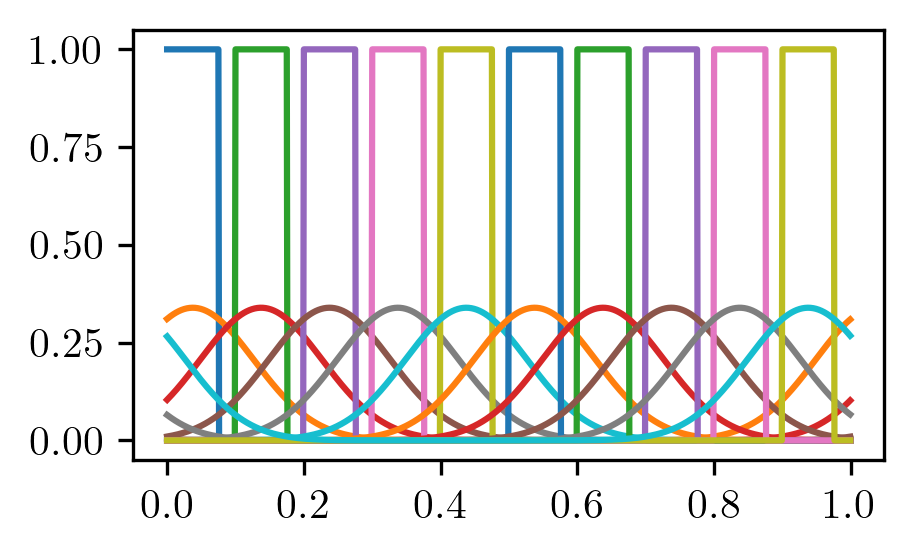

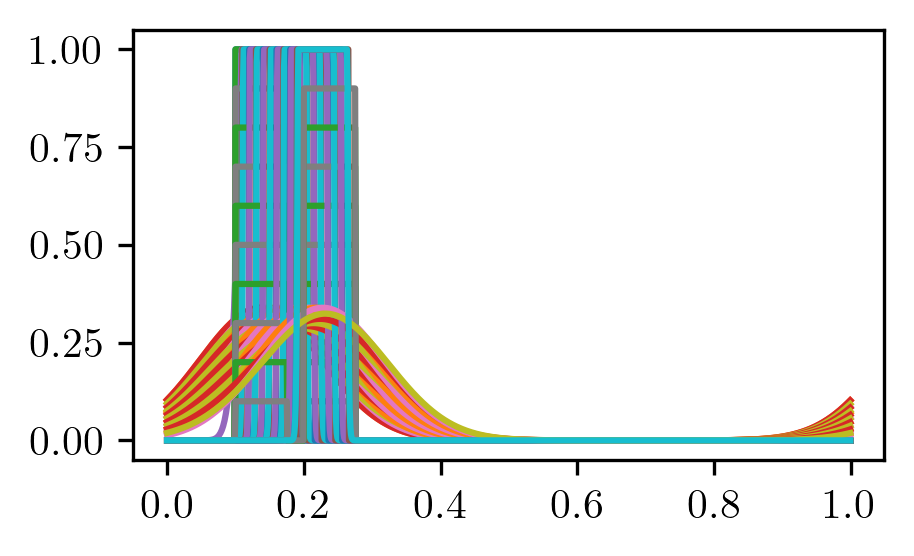

In [37]:
for j in range(10):
    plt.plot(x, X_train[:, j])
    plt.plot(x, X_train_s[:, j])
plt.show()
for j in range(10):
    plt.plot(x, X_test[:, j])
    plt.plot(x, X_test_s[:, j])
    plt.plot(x, X_test_ROM[:, j])
    plt.plot(x, X_test_sROM[:, j])
    plt.plot(x, X_test_sROMs[:, j])
plt.show()

post_process: 0.08658711379158776 2.1672340746863146 1000 (1000,) True
0.08658711, 2.16723407, 40, 0.18630632, 0.21657671, 0.03191978, -82.8670 %

post_process: 0.06684313584241418 0.5735618347803936 1000 (1000,) True
0.06684314, 0.57356183, 65, 0.12004990, 0.19519637, 0.03305869, -72.4625 %

post_process: 0.013486625924013847 0.6776684173001009 1000 (1000,) True
0.01348663, 0.67766842, 59, 0.07592622, 0.08606834, 0.03028604, -60.1112 %

In [9]:
data = X_test_sROM
X_test_sROMs = post_process(
    x,
    data,
    _sigma_,
    _c_,
    mu_test,
    mu_train,
    num_iter,
    shape,
    clip,
    progress=False,
    monitor_convergence=False,
)

e_sROMs = L2_error(X_test_sROMs, X_test)
mean_sROMs = np.mean(e_sROMs)
improvement = 100 * mean_sROMs / mean_ROM - 100
print(
    "{:.8f}, {:.8f},".format(_sigma_, _c_),
    "{:.0f}, {:.8f}, {:.8f}, {:.8f}, {:.4f} %".format(
        0, mean_ROM, mean_sROM, mean_sROMs, improvement
    ),
)

post_process: 0.08658711379158776 2.1672340746863146 1000 (1000,) True
0.08658711, 2.16723407, 0, 0.18630632, 0.21657671, 0.03191978, -82.8670 %


In [11]:
e_sROMs.shape

(10,)

In [16]:
rank

[10, 20, 30, 50]

generate snapshots
build ROM and predict
vary sigma and see what happens with the error
post_process: 0.0 2.147755288610398 1000 (1000,) True
0.21657507060532516 0.18465529060532515
post_process: 0.001 2.147755288610398 1000 (1000,) True
0.21656784919043895 0.18464806919043894
post_process: 0.002 2.147755288610398 1000 (1000,) True
0.21654616965864953 0.18462638965864953
post_process: 0.003 2.147755288610398 1000 (1000,) True
0.21650998607870314 0.18459020607870313
post_process: 0.004 2.147755288610398 1000 (1000,) True
0.216459221660639 0.184539441660639
post_process: 0.005 2.147755288610398 1000 (1000,) True
0.21639376840060867 0.18447398840060866
post_process: 0.006 2.147755288610398 1000 (1000,) True
0.21631348658380817 0.18439370658380816
post_process: 0.007 2.147755288610398 1000 (1000,) True
0.21621820414755843 0.18429842414755843
post_process: 0.008 2.147755288610398 1000 (1000,) True
0.21610771590708758 0.18418793590708757
post_process: 0.009000000000000001 2.147755288610398 1

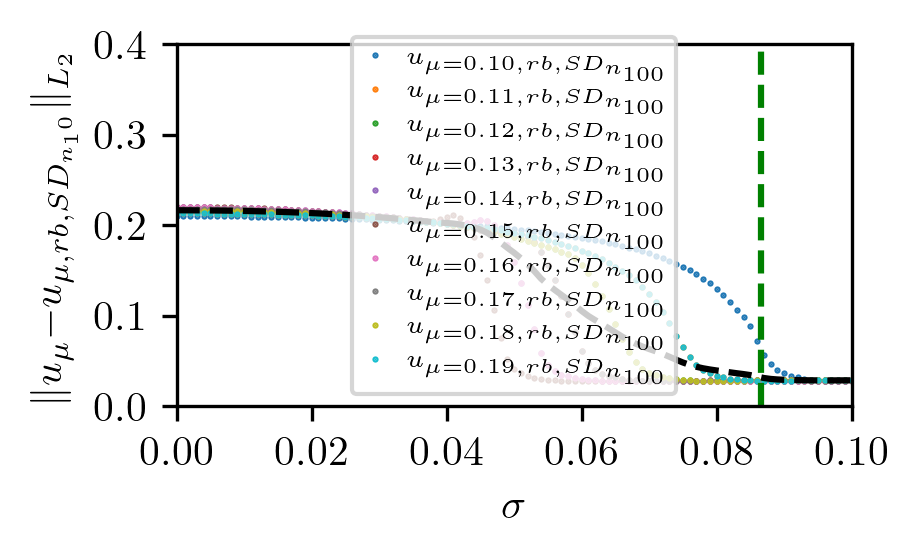

generate snapshots
build ROM and predict
vary sigma and see what happens with the error
post_process: 0.0 0.5273285959317914 1000 (1000,) True
0.19590808932084172 0.1639883093208417
post_process: 0.001 0.5273285959317914 1000 (1000,) True
0.1958984484782184 0.1639786684782184
post_process: 0.002 0.5273285959317914 1000 (1000,) True
0.19586950589997587 0.16394972589997586
post_process: 0.003 0.5273285959317914 1000 (1000,) True
0.19582120132536857 0.16390142132536856
post_process: 0.004 0.5273285959317914 1000 (1000,) True
0.19575343393994077 0.16383365393994076
post_process: 0.005 0.5273285959317914 1000 (1000,) True
0.1956660618047028 0.1637462818047028
post_process: 0.006 0.5273285959317914 1000 (1000,) True
0.19555890104638843 0.16363912104638842
post_process: 0.007 0.5273285959317914 1000 (1000,) True
0.19543172480156365 0.16351194480156364
post_process: 0.008 0.5273285959317914 1000 (1000,) True
0.19528426190266668 0.16336448190266667
post_process: 0.009000000000000001 0.527328595

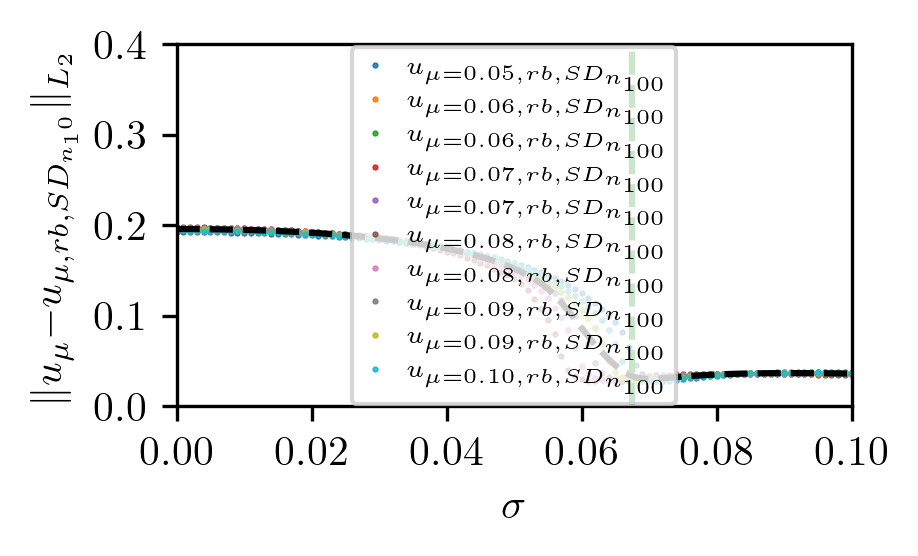

generate snapshots
build ROM and predict
vary sigma and see what happens with the error
post_process: 0.0 0.3269542485762022 1000 (1000,) True
0.1573572817959242 0.1254375017959242
post_process: 0.001 0.3269542485762022 1000 (1000,) True
0.15733085613991318 0.12541107613991317
post_process: 0.002 0.3269542485762022 1000 (1000,) True
0.1572514834020931 0.1253317034020931
post_process: 0.003 0.3269542485762022 1000 (1000,) True
0.1571188754222564 0.12519909542225638
post_process: 0.004 0.3269542485762022 1000 (1000,) True
0.1569325490308538 0.1250127690308538
post_process: 0.005 0.3269542485762022 1000 (1000,) True
0.15669182166303725 0.12477204166303724
post_process: 0.006 0.3269542485762022 1000 (1000,) True
0.15639580511891524 0.12447602511891523
post_process: 0.007 0.3269542485762022 1000 (1000,) True
0.15604339738321257 0.12412361738321256
post_process: 0.008 0.3269542485762022 1000 (1000,) True
0.1556332723807788 0.12371349238077878
post_process: 0.009000000000000001 0.326954248576

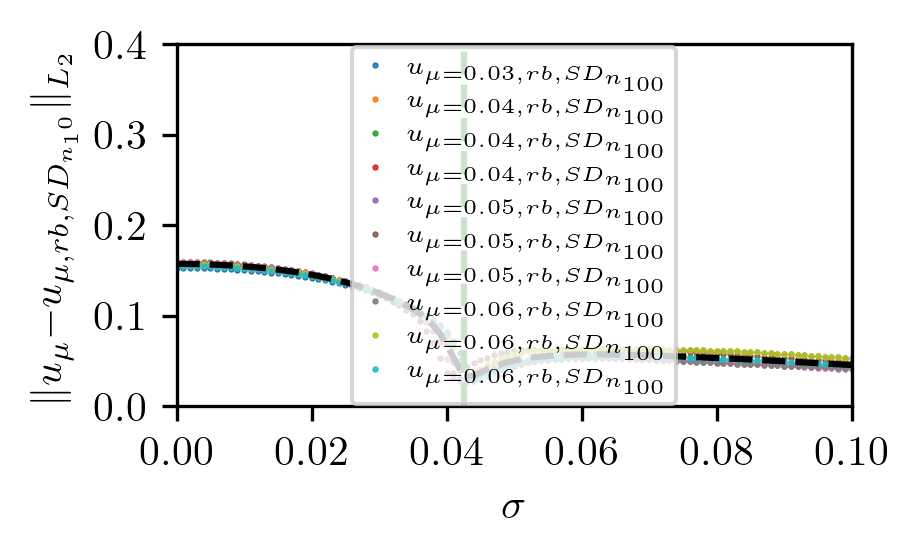

In [22]:
for i, _rank, _sigma, _c in zip((1, 2, 3), rank, sigma, c):
    print("generate snapshots")
    print("build ROM and predict")
    n_train = _rank

    mu_train = np.linspace([0.0], [1.0], n_train, endpoint=False)
    mu_test, X_test, X_test_ROM, X_test_s, X_test_sROM = build_DSROM_g(mu_train, g, x, _sigma, n_test)

    #Fig3(x, mu_train, X_train, X_train_s)

    print("vary sigma and see what happens with the error")
    sigmas = np.linspace(0, 0.1, 101)
    #sigmas = [0.08, 0.08658411693500023, 0.09]
    #c = [2.147755288610398, 0.5273285959317914, 0.3269542485762022, 0.6772697328198871]
    X_test_sROMs = np.empty((n_x, n_test, len(sigmas)))
    for j, __sigma in enumerate(sigmas):
        X_test_sROMs[:, :, j] = post_process(
            x, X_test_sROM, __sigma, _c, mu_test, mu_train, num_iter2, shape, clip=clip, progress=False, monitor_convergence=False
        )
        esROMs = L2_error(X_test_sROMs[:, :, j], X_test)
        #0.03191978, 0.03305869, 0.03028604
        print(np.mean(esROMs), np.mean(esROMs)-0.03191978)

    esROMs = L2_error(X_test_sROMs, X_test[..., None])
    print(esROMs.shape)
    print(
        "{:.8f}, {:.8f},".format(_sigma, _c),
        "{:.0f}, {:.8f}, {:.8f}, {:.8f}, {:.4f} %".format(
            0, .1, .2, np.mean(esROMs), 99.999
        ),
    )
    for j in range(10):
        plt.plot(sigmas, esROMs[j], marker=".", ms=1, lw=0, label=r"$u_{\mu="+"{:.2f}".format(mu_test[j, 0])+",rb,SD_{n_{100}}}$")
    plt.plot(sigmas, np.mean(esROMs, axis=0), "k--")
    plt.plot((_sigma, _sigma), (0, 0.4), "g--")
    plt.legend()
    plt.xlim(0, sigmas[-1])
    plt.ylim(0, .4)
    plt.ylabel(r"$\|u_{\mu}{-u_{\mu, rb, SD_{n_10}}}\|_{L_2}$")
    plt.xlabel(r"$\sigma$")
    plt.show()



generate snapshots
how does the error converge?
post_process: 0.08658711379158776 2.1672340746863146 1000 (1000,) True
(1000, 10)


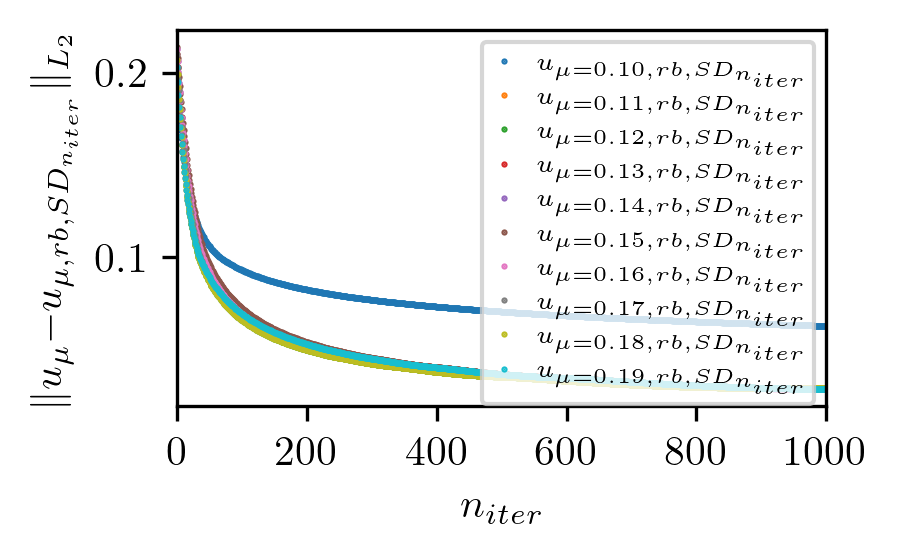

post_process: 0.06684313584241418 2.1672340746863146 1000 (1000,) True
(1000, 10)


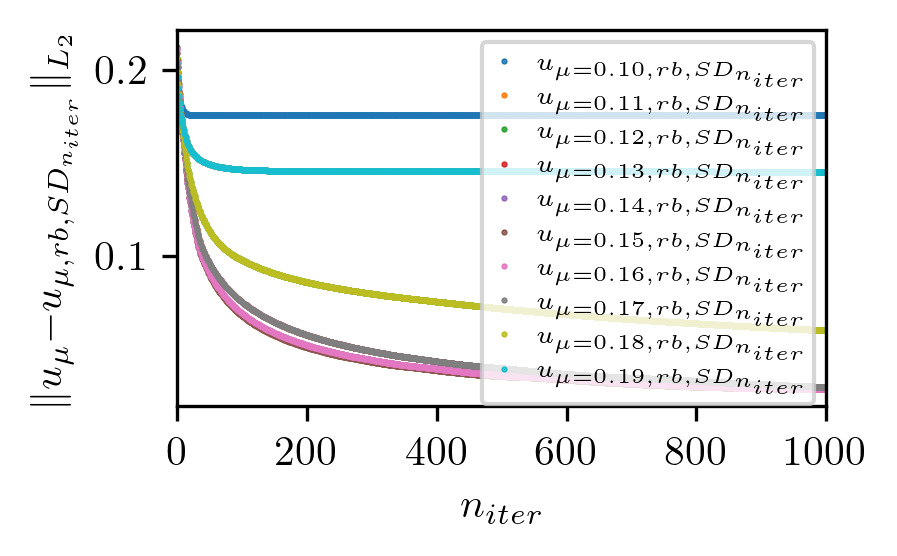

post_process: 0.0427229398625952 2.1672340746863146 1000 (1000,) True
(1000, 10)


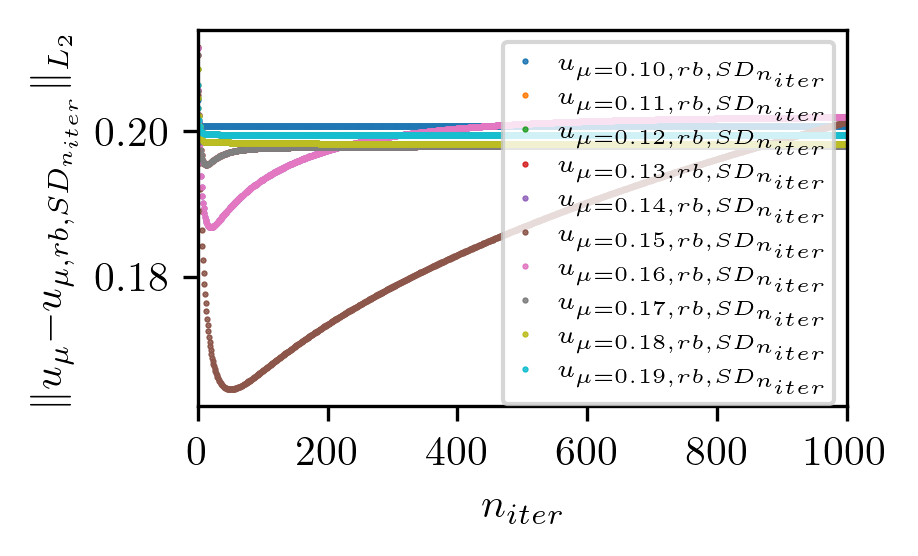

post_process: 0.013486625924013847 2.1672340746863146 1000 (1000,) True
(1000, 10)


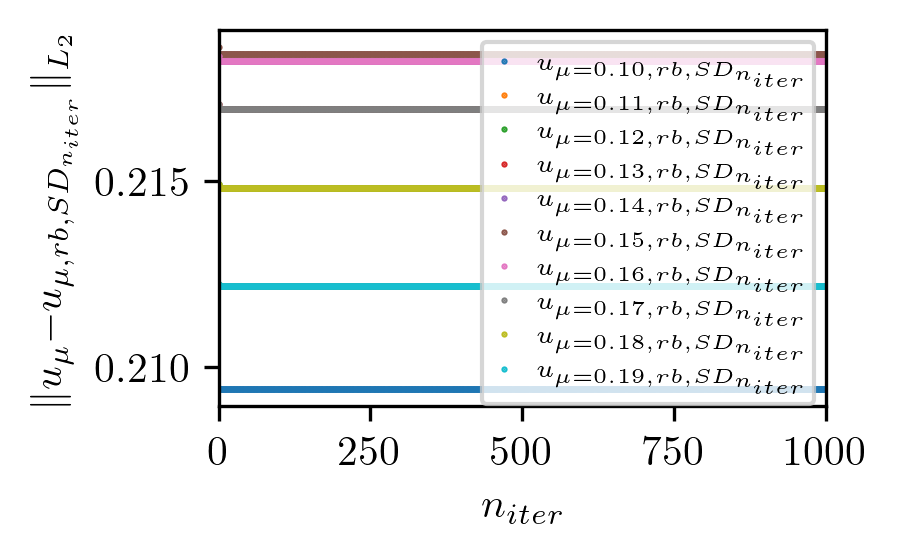

generate snapshots
how does the error converge?
post_process: 0.08658711379158776 0.5235618347803935 1000 (1000,) True
(1000, 10)


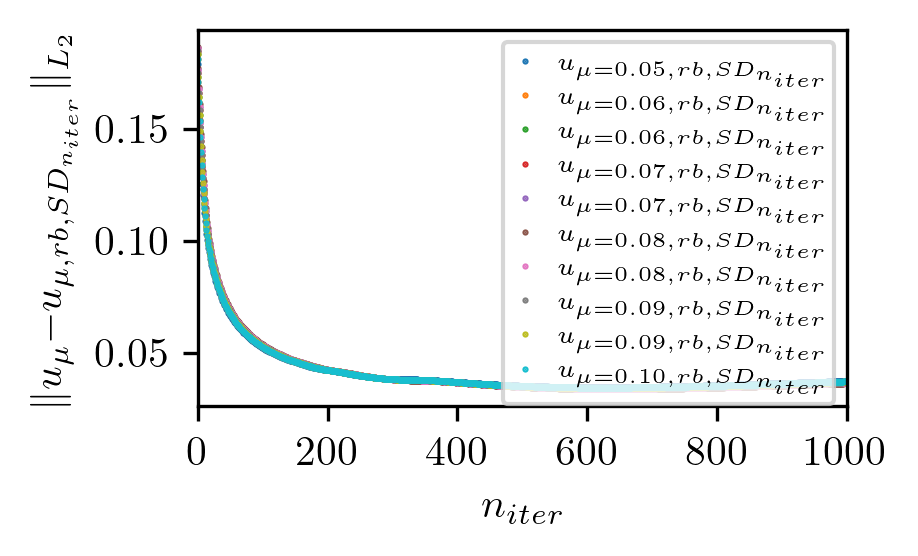

post_process: 0.06684313584241418 0.5235618347803935 1000 (1000,) True
(1000, 10)


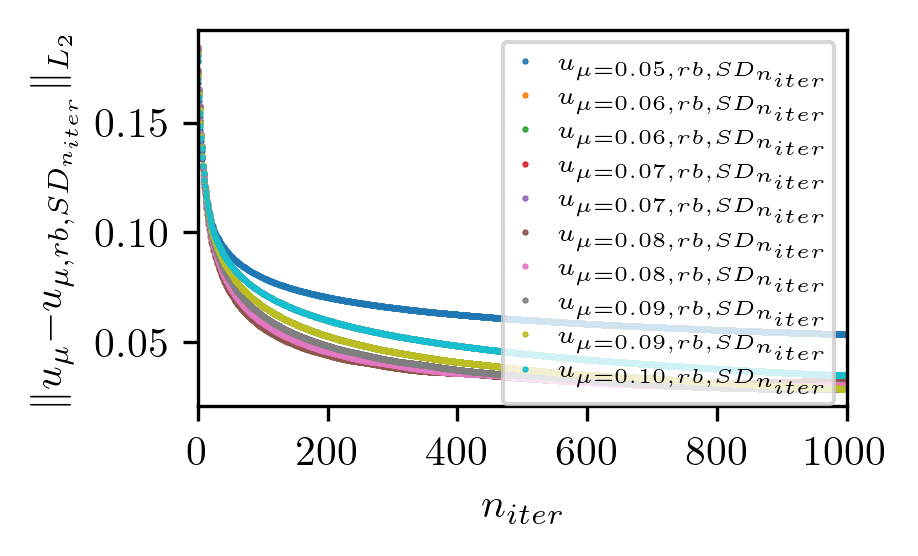

post_process: 0.0427229398625952 0.5235618347803935 1000 (1000,) True
(1000, 10)


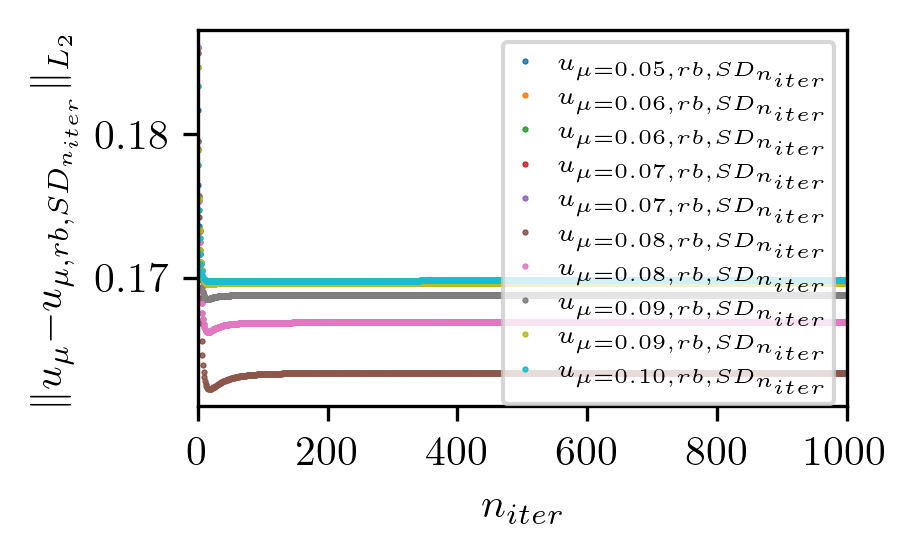

post_process: 0.013486625924013847 0.5235618347803935 1000 (1000,) True
(1000, 10)


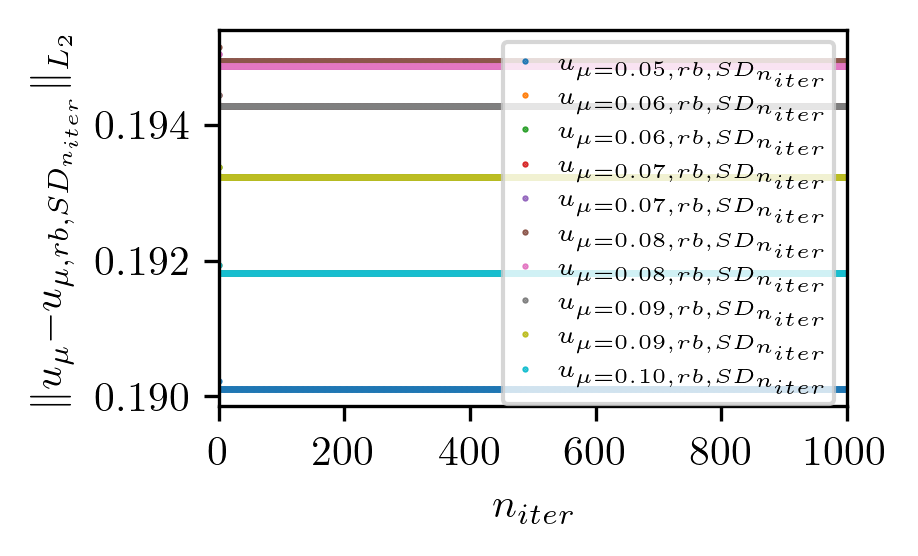

generate snapshots
how does the error converge?
post_process: 0.08658711379158776 0.32587394154986854 1000 (1000,) True
(1000, 10)


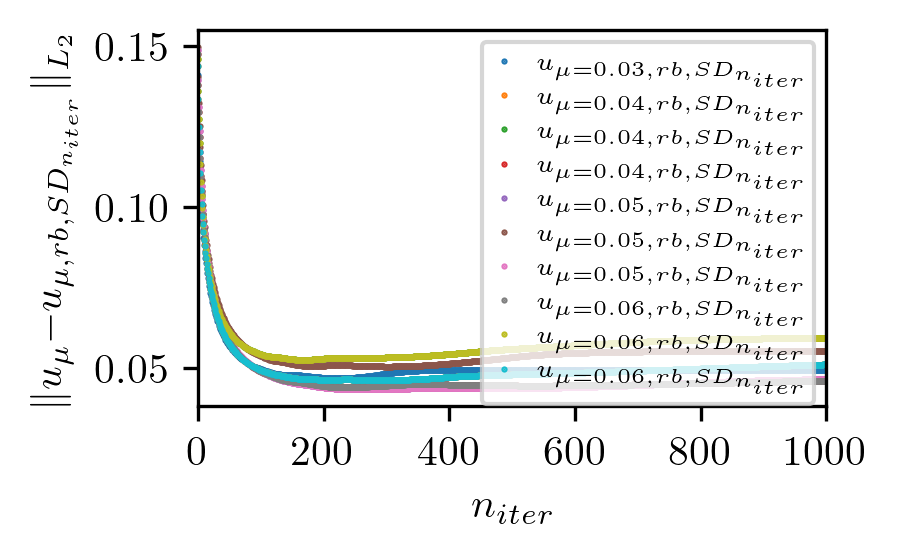

post_process: 0.06684313584241418 0.32587394154986854 1000 (1000,) True
(1000, 10)


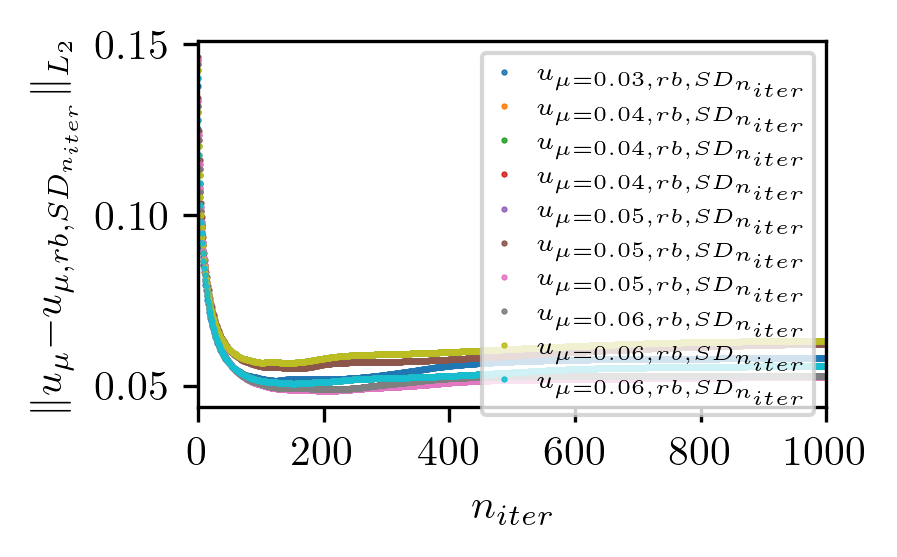

post_process: 0.0427229398625952 0.32587394154986854 1000 (1000,) True
(1000, 10)


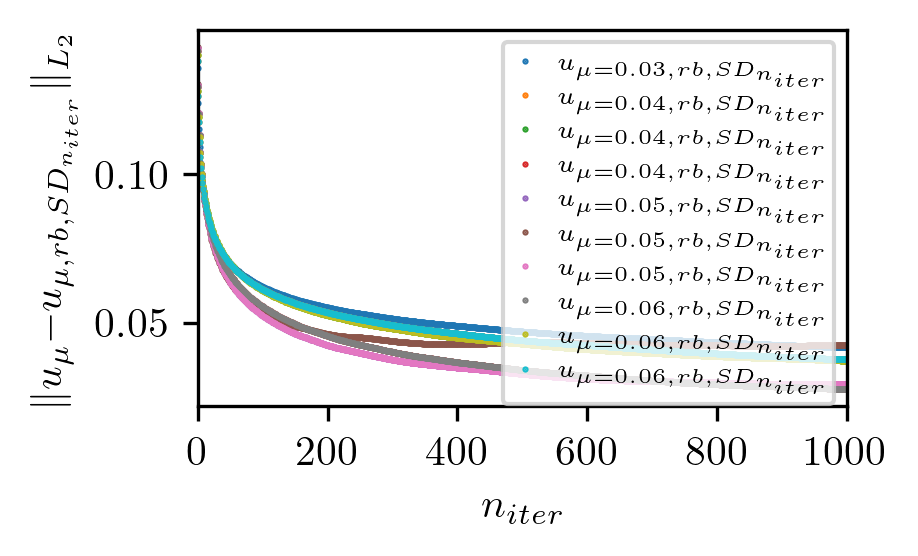

post_process: 0.013486625924013847 0.32587394154986854 1000 (1000,) True
(1000, 10)


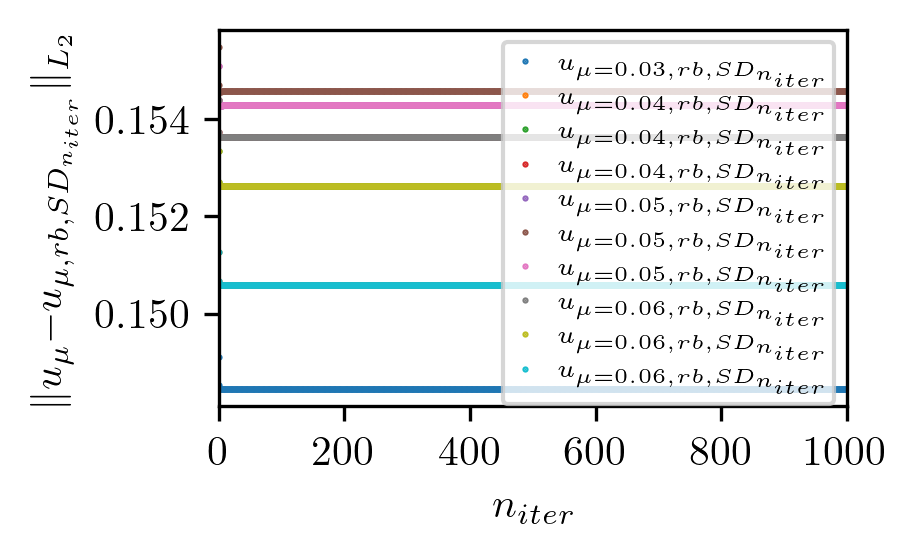

generate snapshots
how does the error converge?
post_process: 0.08658711379158776 0.6776684173001009 1000 (1000,) True
(1000, 10)


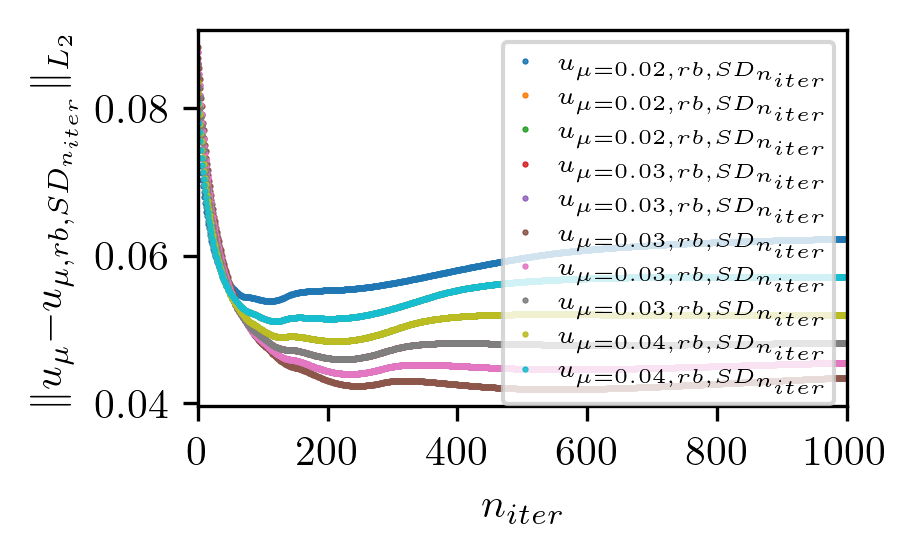

post_process: 0.06684313584241418 0.6776684173001009 1000 (1000,) True
(1000, 10)


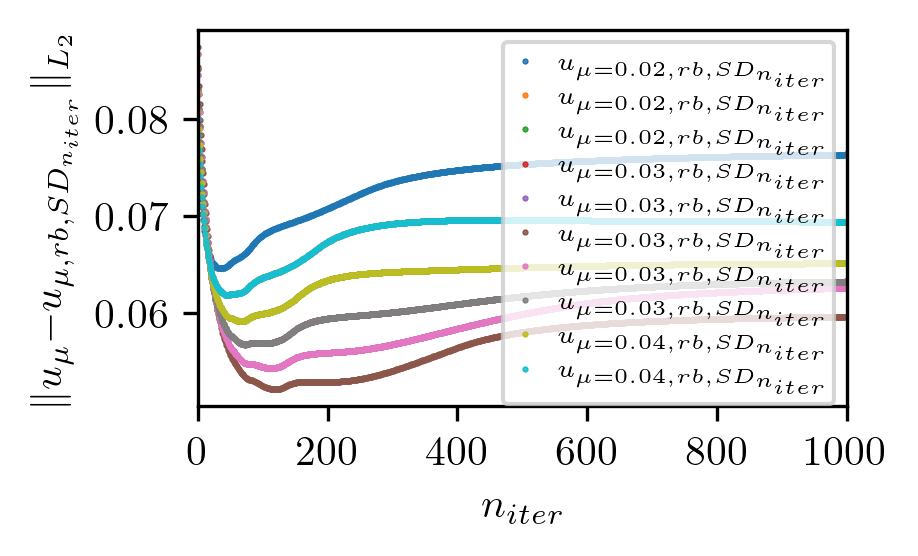

post_process: 0.0427229398625952 0.6776684173001009 1000 (1000,) True
(1000, 10)


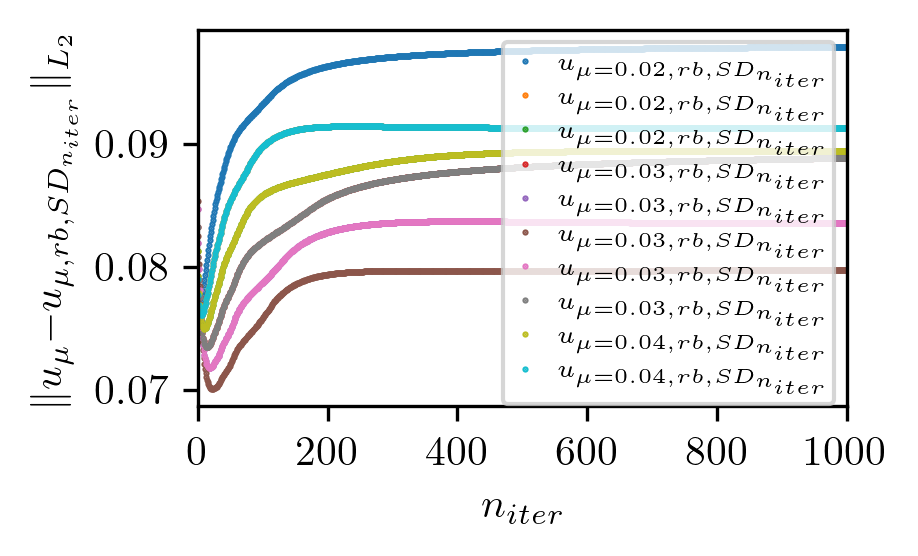

post_process: 0.013486625924013847 0.6776684173001009 1000 (1000,) True
(1000, 10)


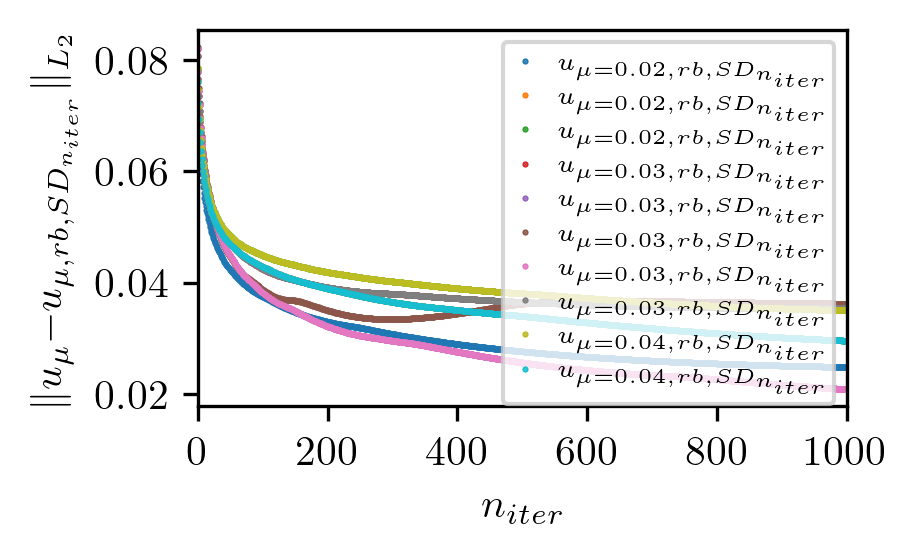

In [8]:
for _rank, _sigma, _c in zip(rank, sigma, c):
    print("generate snapshots")
    n_train = _rank
    mu_train = np.linspace([0.0], [1.0], n_train, endpoint=False)

    mu_test, X_test, X_test_ROM, X_test_s, X_test_sROM = build_DSROM_g(mu_train, g, x, _sigma, n_test)


    print("how does the error converge?")
    for j, __sigma in enumerate(sigma):
        X_test_sROMs = post_process(
            x, X_test_sROM, __sigma, _c, mu_test, mu_train, num_iter2, shape, clip=clip, progress=False, monitor_convergence=True
        )
        print(X_test_sROM.shape)
        eROM = L2_error(X_test_ROM, X_test)
        esROM = L2_error(X_test_sROM, X_test)
        esROMs = L2_error(X_test_sROMs, X_test[..., None])

        # plot
        for j in range(10):
            plt.plot(esROMs[j], marker=".", ms=1, lw=0, label=r"$u_{\mu="+"{:.2f}".format(mu_test[j, 0])+",rb,SD_{n_{iter}}}$")
        plt.legend()
        plt.xlim(0, num_iter2)
        plt.ylabel(r"$\|u_{\mu}{-u_{\mu, rb, SD_{n_{iter}}}}\|_{L_2}$")
        plt.xlabel(r"$n_{iter}$")
        plt.show()

In [9]:
# X_test_sROMs = post_process(
#     x, X_test_sROM, __sigma, _c, mu_test, mu_train, num_iter2, shape, clip=clip, progress=False, monitor_convergence=True
# )
# print(X_test_sROM.shape)
# eROM = L2_error(X_test_ROM, X_test)
# esROM = L2_error(X_test_sROM, X_test)
# esROMs = L2_error(X_test_sROMs, X_test[..., None])

In [10]:
# optimize_hyperparameters(x, mu_train, mu_test, X_train, X_test, shape, num_iter2, clip, rank)
# # calls zielfunktion, which does the following:

# standard_rom = train_ROM(mu_train, X_train, rank=rank)
# X_test_ROM = standard_rom.predict(mu_test).snapshots_matrix.T
# e_ROM = L2_error(X_test_ROM, X_test)
# mean_ROM = np.mean(e_ROM)

# X_train_s = smoothen(X_train, sigma / dx, shape)
# smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
# X_test_sROM = smooth_rom.predict(mu_test).snapshots_matrix.T
# e_sROM = L2_error(X_test_sROM, X_test)
# mean_sROM = np.mean(e_sROM)
# X_test_sROMs = post_process(
#     x, X_test_sROM, sigma, c, mu_test, mu_train, num_iter, shape=shape, clip=clip
# )
# e_sROMs = L2_error(X_test_sROMs, X_test)
# mean_sROMs = np.mean(e_sROMs)
# improvement = 100 * mean_sROMs / mean_ROM - 100